# Fashion-MNIST Clothing Classification
**Course:** Artificial Neural Networks  
**Model:** Multi-Layer Perceptron (MLP)  
**Dataset:** Fashion-MNIST — 60,000 training images, 10 clothing classes  
**Experiment:** ReLU vs Sigmoid activation functions

## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/fashion_mnist_project/results', exist_ok=True)
print('Drive mounted and results folder ready.')

Mounted at /content/drive
Drive mounted and results folder ready.


## Cell 2 — Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3 — Load & Preprocess Data

In [3]:

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('--- Before Preprocessing ---')
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'Pixel range   : {X_train.min()} to {X_train.max()}')

# Normalize pixel values
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Flatten images
X_train = X_train.reshape(-1, 784)
X_test  = X_test.reshape(-1, 784)

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

print('\n--- After Preprocessing ---')
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train_cat.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
--- Before Preprocessing ---
X_train shape : (60000, 28, 28)
X_test shape  : (10000, 28, 28)
Pixel range   : 0 to 255

--- After Preprocessing ---
X_train : (60000, 784)
X_test  : (10000, 784)
y_train : (60000, 10)


In [4]:

print('--- Data Quality Checks ---')
print(f'NaN values in X_train: {np.isnan(X_train).sum()}')
print(f'NaN values in X_test : {np.isnan(X_test).sum()}')
print(f'NaN values in y_train: {np.isnan(y_train).sum()}')
print(f'NaN values in y_test : {np.isnan(y_test).sum()}')
print(f'Pixel range after normalization: [{X_train.min():.1f}, {X_train.max():.1f}]')
print(f'Unique labels: {np.unique(y_train)}')
print(f'Label distribution (train): {np.bincount(y_train)}')
print('\nNo missing values found. No imputation needed.')
print('No categorical variables to encode — labels are already integers 0–9.')

--- Data Quality Checks ---
NaN values in X_train: 0
NaN values in X_test : 0
NaN values in y_train: 0
NaN values in y_test : 0
Pixel range after normalization: [0.0, 1.0]
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Label distribution (train): [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]

No missing values found. No imputation needed.
No categorical variables to encode — labels are already integers 0–9.


## Cell 4 — Visualize Sample Images

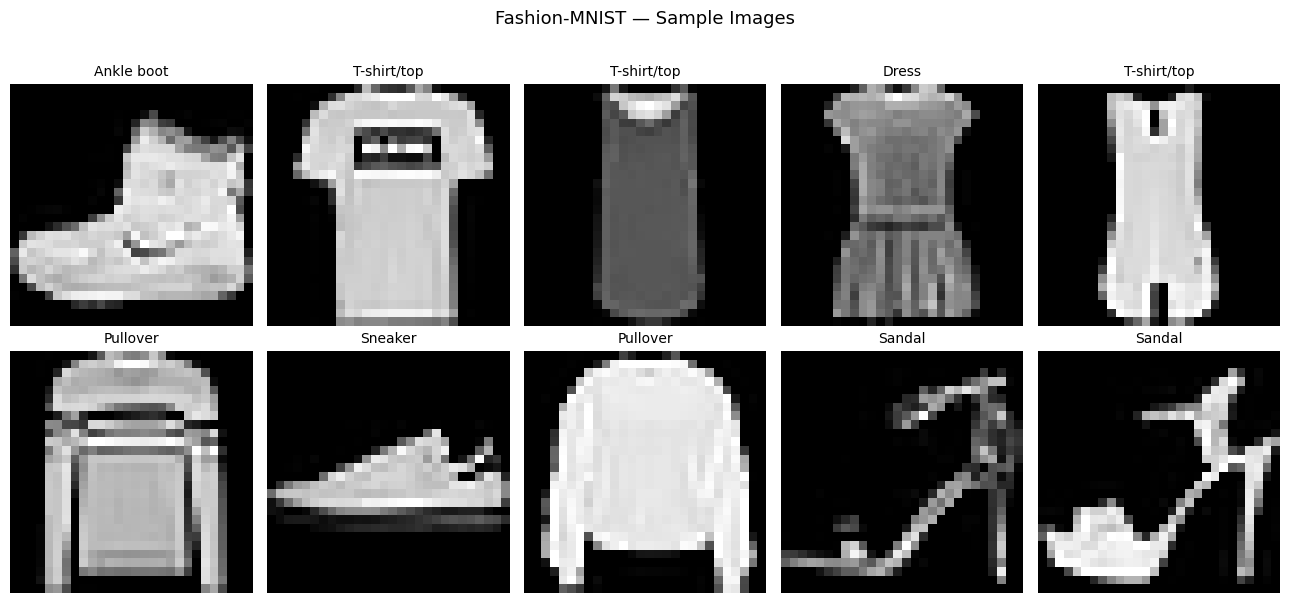

Saved: sample_images.png


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Fashion-MNIST — Sample Images', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fashion_mnist_project/results/sample_images.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

## Cell 5 — Experiment A: Model with ReLU Activation (Baseline)

In [6]:
# ============================================================
# EXPERIMENT A — Adam optimizer + ReLU activation (baseline)
# ============================================================

model_A = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10,  activation='softmax')
])

model_A.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_A.summary()

print('Training Model A (ReLU)...')
history_A = model_A.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

loss_A, acc_A = model_A.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nModel A (ReLU) — Test Accuracy: {acc_A:.4f} | Test Loss: {loss_A:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Training Model A (ReLU)...
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7855 - loss: 0.5964 - val_accuracy: 0.8478 - val_loss: 0.4108
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8444 - loss: 0.4310 - val_accuracy: 0.8633 - val_loss: 0.3734
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8564 - loss: 0.3936 - val_accuracy: 0.8661 - val_loss: 0.3738
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8642 - loss: 0.3718 - val_accuracy: 0.8695 - val_loss: 0.3546
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8686 - loss: 0.3563 - val_accuracy: 0.8767 - val_loss: 0.3352
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8745 - loss: 0.3404 - val_accuracy: 0.8808 - val_loss: 0.3316
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8755 - loss: 0.3316 - val_accuracy: 0.8817 - val_loss: 0.3220
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8822 - loss

## Cell 6 — Experiment B: Model with Sigmoid Activation

In [7]:
# ============================================================
# EXPERIMENT B — Adam optimizer + Sigmoid activation
# Only change: ReLU -> Sigmoid. Everything else identical.
# ============================================================

model_B = Sequential([
    Dense(256, activation='sigmoid', input_shape=(784,)),
    Dropout(0.3),
    Dense(128, activation='sigmoid'),
    Dropout(0.2),
    Dense(10,  activation='softmax')
])

model_B.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Model B (Sigmoid)...')
history_B = model_B.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

loss_B, acc_B = model_B.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nModel B (Sigmoid) — Test Accuracy: {acc_B:.4f} | Test Loss: {loss_B:.4f}')

Training Model B (Sigmoid)...
Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7404 - loss: 0.7398 - val_accuracy: 0.8311 - val_loss: 0.4649
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8323 - loss: 0.4666 - val_accuracy: 0.8548 - val_loss: 0.4029
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8501 - loss: 0.4204 - val_accuracy: 0.8602 - val_loss: 0.3808
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8584 - loss: 0.3926 - val_accuracy: 0.8670 - val_loss: 0.3621
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8631 - loss: 0.3742 - val_accuracy: 0.8728 - val_loss: 0.3487
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8701 - loss: 0.3594 - val_accuracy: 0.8728 - val_loss: 0.3433
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8732 - loss: 0.3464 - val_accuracy: 0.8720 - val_loss: 0.3503
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8780 - l

## Cell 7 — Plot Training Curves (Both Models)

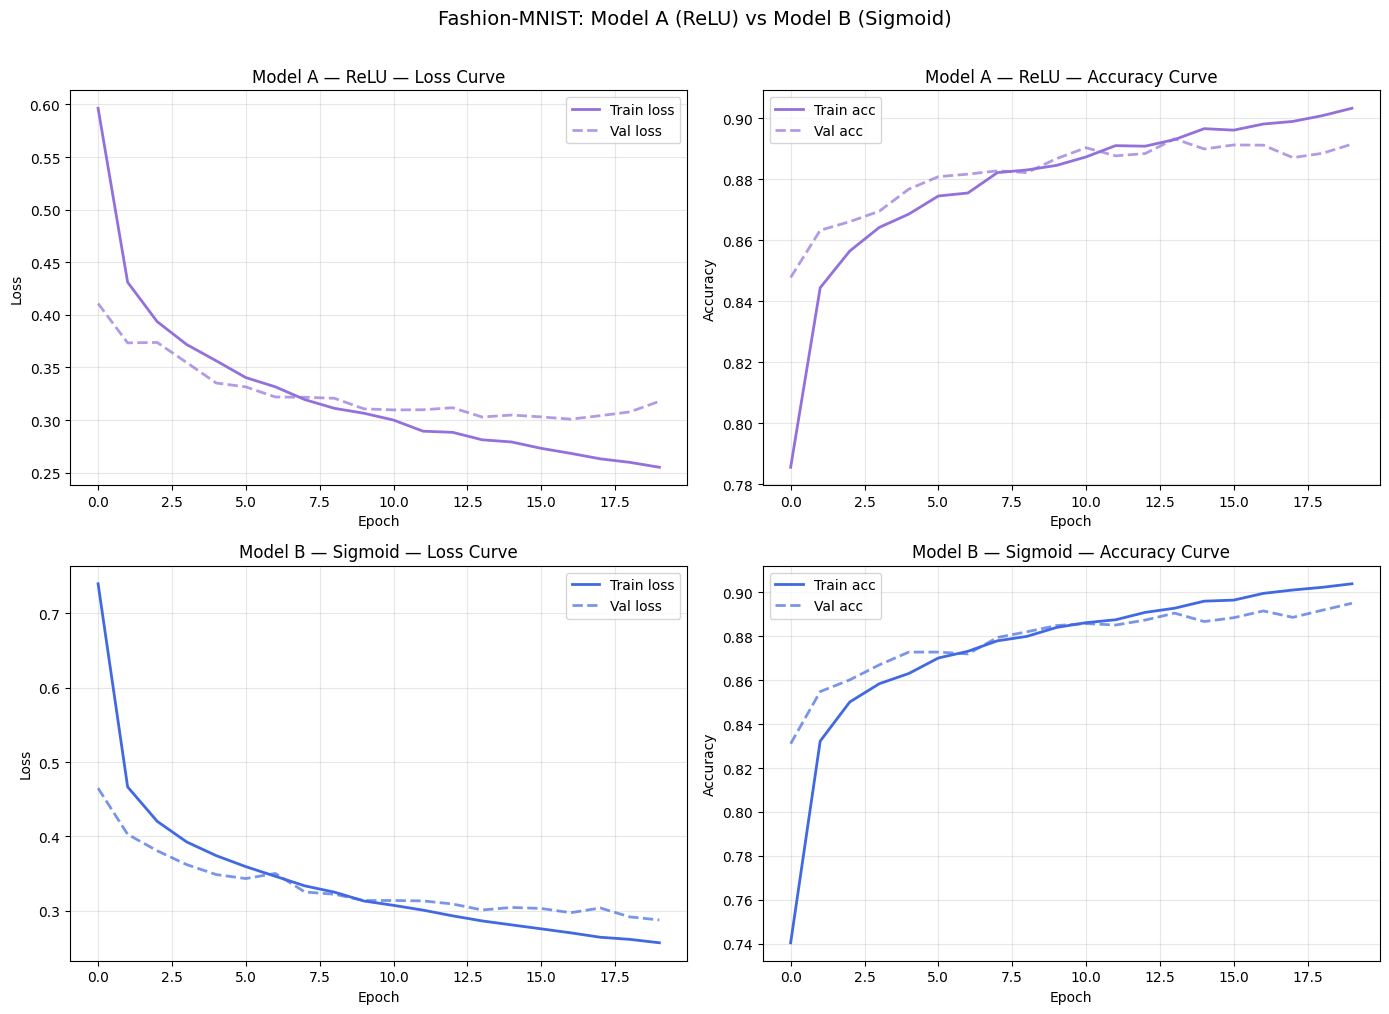

Saved: training_curves.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (hist, name, color) in enumerate([
    (history_A, 'Model A — ReLU',    '#9370db'),
    (history_B, 'Model B — Sigmoid', '#4169e1')
]):
    # Loss curve
    axes[i][0].plot(hist.history['loss'],     label='Train loss', color=color,      linewidth=2)
    axes[i][0].plot(hist.history['val_loss'], label='Val loss',   color=color, linestyle='--', linewidth=2, alpha=0.7)
    axes[i][0].set_title(f'{name} — Loss Curve', fontsize=12)
    axes[i][0].set_xlabel('Epoch')
    axes[i][0].set_ylabel('Loss')
    axes[i][0].legend()
    axes[i][0].grid(alpha=0.3)

    # Accuracy curve
    axes[i][1].plot(hist.history['accuracy'],     label='Train acc', color=color,      linewidth=2)
    axes[i][1].plot(hist.history['val_accuracy'], label='Val acc',   color=color, linestyle='--', linewidth=2, alpha=0.7)
    axes[i][1].set_title(f'{name} — Accuracy Curve', fontsize=12)
    axes[i][1].set_xlabel('Epoch')
    axes[i][1].set_ylabel('Accuracy')
    axes[i][1].legend()
    axes[i][1].grid(alpha=0.3)

plt.suptitle('Fashion-MNIST: Model A (ReLU) vs Model B (Sigmoid)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fashion_mnist_project/results/training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## Cell 8 — Results Comparison Table

In [9]:
print('=' * 50)
print(f'{"Model":<25} {"Accuracy":>10} {"Loss":>10}')
print('=' * 50)
print(f'{"Model A (ReLU)":<25} {acc_A:>10.4f} {loss_A:>10.4f}')
print(f'{"Model B (Sigmoid)":<25} {acc_B:>10.4f} {loss_B:>10.4f}')
print('=' * 50)

better = 'Model A (ReLU)' if acc_A >= acc_B else 'Model B (Sigmoid)'
diff   = abs(acc_A - acc_B) * 100
print(f'\nBest model: {better} (difference: {diff:.2f}%)')

Model                       Accuracy       Loss
Model A (ReLU)                0.8835     0.3383
Model B (Sigmoid)             0.8867     0.3154

Best model: Model B (Sigmoid) (difference: 0.32%)


## Cell 9 — Classification Report (Model A)

In [10]:
y_pred_A = np.argmax(model_A.predict(X_test), axis=1)

print('Classification Report — Model A (ReLU):')
print(classification_report(y_test, y_pred_A, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Classification Report — Model A (ReLU):
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.79      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.80      0.80      1000
       Dress       0.86      0.90      0.88      1000
        Coat       0.82      0.79      0.80      1000
      Sandal       0.95      0.98      0.96      1000
       Shirt       0.68      0.74      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



## Cell 10 — Confusion Matrix (Model A)

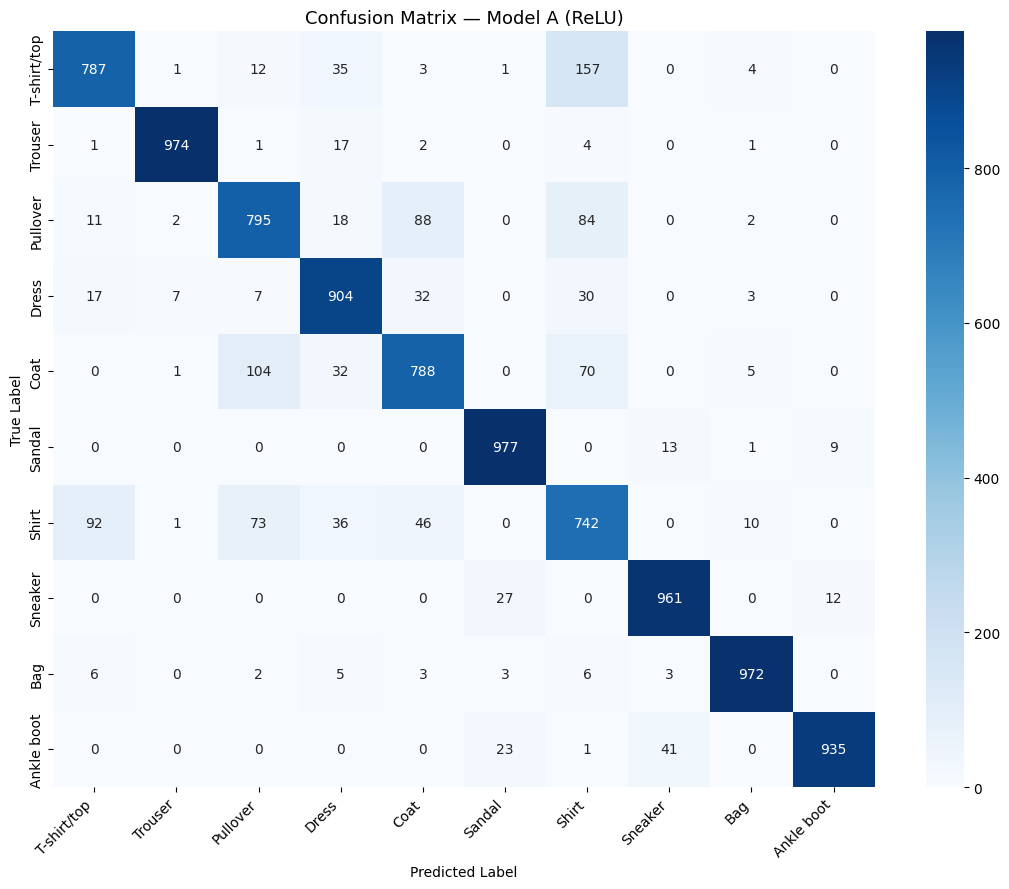

Saved: confusion_matrix.png


In [11]:
cm = confusion_matrix(y_test, y_pred_A)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Model A (ReLU)', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fashion_mnist_project/results/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## Cell 11 — Save Model

In [12]:
model_A.save('/content/drive/MyDrive/fashion_mnist_project/model_A_relu.h5')
model_B.save('/content/drive/MyDrive/fashion_mnist_project/model_B_sigmoid.h5')
print('Both models saved to Google Drive.')

Both models saved to Google Drive.


## Cell 12 — Test on an External Image
Upload any clothing image to Colab (`Files` panel → Upload), copy its path, paste it into `IMAGE_PATH` below, and run the cell.

The cell will display your image alongside the model's **top-3 predictions** with confidence scores.

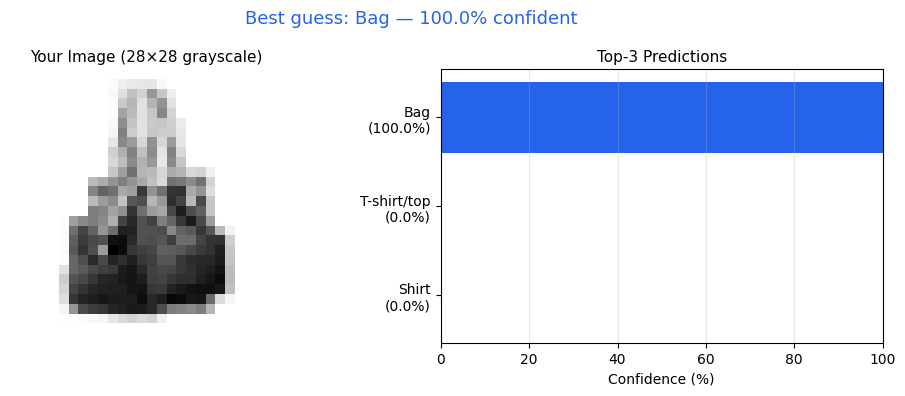


── Top-3 Predictions ──────────────────────────
  #1: Bag             100.00%
  #2: T-shirt/top       0.00%
  #3: Shirt             0.00%


In [14]:
# ── Cell 12 · Test on an External Image ──────────────────────────────────
from PIL import Image
# ↓↓↓ PASTE YOUR IMAGE PATH HERE ↓↓↓
IMAGE_PATH = '/content/Ladies-Bag-PNG-Transparent-Image.png'

img_pil = Image.open(IMAGE_PATH).convert('L')

# Resize to 28×28 — the exact size the model was trained on.
img_resized = img_pil.resize((28, 28))

# Convert to numpy array and normalise to [0, 1]
img_array = np.array(img_resized, dtype=np.float32) / 255.0

# Flatten from (28, 28) to (784,) — MLP expects a 1D vector, not a 2D grid.
# Then add a batch dimension
img_flat = img_array.flatten()[np.newaxis, :]

probs = model_A.predict(img_flat, verbose=0)[0]

top3_indices = np.argsort(probs)[::-1][:3]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_resized, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Your Image (28×28 grayscale)', fontsize=11)

bar_labels = [f"{CLASS_NAMES[i]}\n({probs[i]*100:.1f}%)" for i in top3_indices]
bar_values = [probs[i] * 100 for i in top3_indices]
bar_colors = ['#2563EB', '#7C3AED', '#6B7280']

axes[1].barh(bar_labels[::-1], bar_values[::-1], color=bar_colors[::-1])
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('Top-3 Predictions', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle(
    f'Best guess: {CLASS_NAMES[top3_indices[0]]} — {probs[top3_indices[0]]*100:.1f}% confident',
    fontsize=13, color='#2563EB'
)
plt.tight_layout()
plt.show()

print('\n── Top-3 Predictions ──────────────────────────')
for rank, idx in enumerate(top3_indices, start=1):
    print(f'  #{rank}: {CLASS_NAMES[idx]:<15} {probs[idx]*100:6.2f}%')
